
## **Trains an XGBoost classifier for Ethereum wallet anomaly detection.**

This notebook supports experimentation and justification.

In [1]:
import pandas as pd
import xgboost as xgb
import joblib
import json
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/processed/final/final_train_data.parquet"

FEATURE_COLUMNS = [
    # On-Chain (4)
    'normal_total_cnt',
    'uniq_peers_cnt',
    'burst_max_tx_5m',
    'normal_sent_cnt',
    # Reddit (3)
    'reddit_fraud_mention_ratio',
    'reddit_total_activity',
    'reddit_avg_sentiment',
    # Market (3)
    'eth_volatility_7d',
    'eth_daily_return',
    'eth_intraday_volatility'
]

TARGET_COLUMN = 'is_anomalous'

**Data Loading and Inspection**

In [3]:
df = pd.read_parquet(DATA_PATH)
df.shape, df.columns

((59575, 13),
 Index(['address', 'day', 'is_anomalous', 'normal_total_cnt', 'uniq_peers_cnt',
        'burst_max_tx_5m', 'normal_sent_cnt', 'reddit_fraud_mention_ratio',
        'reddit_total_activity', 'reddit_avg_sentiment', 'eth_volatility_7d',
        'eth_daily_return', 'eth_intraday_volatility'],
       dtype='object'))

In [4]:
display(df.head())

print("\nTarget Distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True))

,address,day,is_anomalous,normal_total_cnt,uniq_peers_cnt,burst_max_tx_5m,normal_sent_cnt,reddit_fraud_mention_ratio,reddit_total_activity,reddit_avg_sentiment,eth_volatility_7d,eth_daily_return,eth_intraday_volatility
0,0xd624d046edbdef805c5e4140dce5fb5ec1b39a3c,2017-03-15,0,2,2,2,1,0.077586,580,0.371972,0.080752,0.223395,0.231198
1,0xc859d7753a0295d8b88be34014a4956e15a2b745,2017-03-28,0,2,2,2,1,0.069388,735,0.338754,0.086855,0.022309,0.036435
2,0xc859d7753a0295d8b88be34014a4956e15a2b745,2017-03-29,0,1,1,2,1,0.055385,650,0.298511,0.084683,0.046306,0.065662
3,0xbad41e5412ebaf22b8ec127521060fd9fa29bbdd,2017-04-14,0,2,2,2,1,0.073171,369,0.324839,0.050267,-0.052675,0.065790
4,0xcda94feb23fbf1c4ca73b45de92e1a4cc2bd40ab,2017-05-16,0,1,1,2,0,0.064205,623,0.304364,0.020178,-0.032212,0.048031



Target Distribution:
is_anomalous
0    0.501956
1    0.498044
Name: proportion, dtype: float64


In [5]:
df['is_anomalous'].value_counts()


is_anomalous
0    29904
1    29671
Name: count, dtype: int64

In [6]:
print(f"\nUnique addresses: {df['address'].nunique()}")



Unique addresses: 2771


**ADDRESS-LEVEL TRAIN/TEST SPLIT (Prevents Data Leakage)**

* To prevent temporal and entity-level data leakage, the dataset is split
* at the wallet address level rather than the transaction-day level.
* All daily records belonging to a given address are assigned exclusively
* to either the training or test set.

In [7]:
from sklearn.model_selection import train_test_split

addresses = df['address'].unique()
train_addr, test_addr = train_test_split(addresses, test_size=0.2, random_state=42)

train_df = df[df['address'].isin(train_addr)]
test_df = df[df['address'].isin(test_addr)]

In [8]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

overlap = set(train_addr) & set(test_addr)
print(f"address overlap: {len(overlap)}")
print(f"Train set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

address overlap: 0
Train set: 48058
Test set: 11517


**Hyperparameter tuning**

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupKFold

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3]
}

groups = train_df['address']
cv = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train, groups=groups)

print(f"Best params: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")

Best params: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}
Best ROC-AUC: 0.7875


**Model Training**

In [10]:
best_params = grid_search.best_params_
model = xgb.XGBClassifier(
    **best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

**Evaluation and Visualizations**

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.71      0.75      0.73      5763
   Anomalous       0.73      0.69      0.71      5754

    accuracy                           0.72     11517
   macro avg       0.72      0.72      0.72     11517
weighted avg       0.72      0.72      0.72     11517



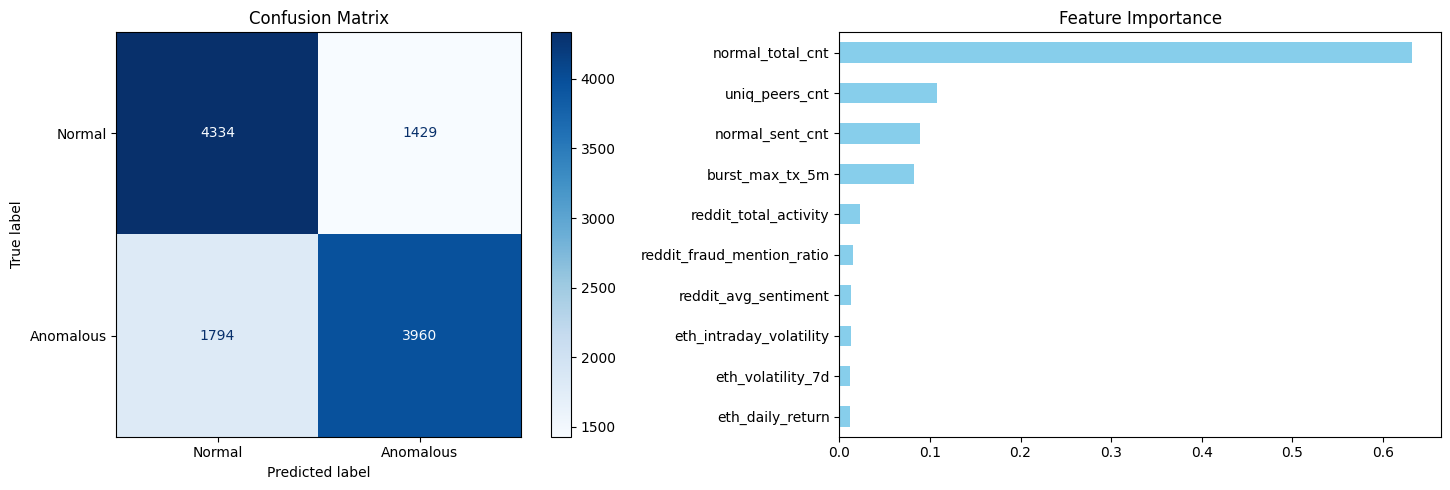

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

y_pred = model.predict(X_test) # 0.5 default threshold
y_prob = model.predict_proba(X_test)[:,1]

# Metrics
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomalous']))

# Plot Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Normal', 'Anomalous'], cmap='Blues', ax=ax1)
ax1.set_title("Confusion Matrix")

# Plot Feature Importance
importance = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
importance.plot(kind='barh', ax=ax2, color='skyblue')
ax2.set_title("Feature Importance")

plt.tight_layout()
plt.show()

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_prob),
    'feature_importance': dict(zip(FEATURE_COLUMNS, model.feature_importances_.tolist())),
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
}

ROC AUC: 0.7801220054280755


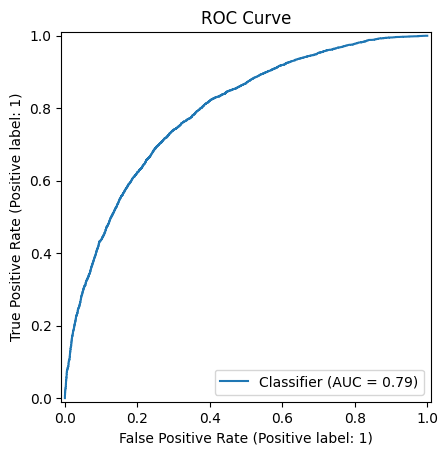

In [12]:
from sklearn.metrics import average_precision_score, RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
print(f"ROC AUC: {average_precision_score(y_test, y_prob)}")
plt.title("ROC Curve")
plt.show()


In [13]:
importance = pd.Series(model.feature_importances_,index=FEATURE_COLUMNS).sort_values(ascending=False)
importance


normal_total_cnt              0.632566
uniq_peers_cnt                0.108172
normal_sent_cnt               0.089344
burst_max_tx_5m               0.082761
reddit_total_activity         0.022590
reddit_fraud_mention_ratio    0.014501
reddit_avg_sentiment          0.013180
eth_intraday_volatility       0.012795
eth_volatility_7d             0.012142
eth_daily_return              0.011949
dtype: float32

**Exporting the Model**

In [14]:
MODEL_PATH = "../../models/xgboost_model.joblib"
METRICS_PATH = "../../models/model_metrics.json"

print(f"Saving model to {MODEL_PATH}...")
joblib.dump({
    'model': model,
    'feature_columns': FEATURE_COLUMNS,
    'target_column': TARGET_COLUMN
}, MODEL_PATH)

print(f"Saving metrics to {METRICS_PATH}...")
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved")

Saving model to ../../models/xgboost_model.joblib...
Saving metrics to ../../models/model_metrics.json...
Saved
